In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Data imports #

# Imports for plot c
s_profs=np.load('s.npy',allow_pickle=True) # this is s not rho
# s_profs=np.broadcast_to(s_profs[None,...],(2,len(s_profs)))
omega_zetas=np.load('freq.npy',allow_pickle=True)

# Imports for Poincares
etas_all_KE0 = np.load('poinc_QSbreak__etas0.npy',allow_pickle=True)
etas_all_KE1 = np.load('poinc_noQSbreak__etas0.npy',allow_pickle=True)
s_all_KE0 = np.load('poinc_QSbreak__s0.npy',allow_pickle=True)
s_all_KE1 = np.load('poinc_noQSbreak__s0.npy',allow_pickle=True)

etas_all = [etas_all_KE0,etas_all_KE1]
s_all = [s_all_KE0,s_all_KE1]

In [5]:
# Resonance stuff #

# Rational numbers
p_max=4
q_max=4
res_range_min = -2
res_range_max = 2
res_arr = np.array([])
# q_arr = np.array([])
res_arr_set = 0

# including the zero resonance
res_arr = np.append(res_arr,0)

for p in range(1,p_max+1): # include the zero resonance
    for q in range(1,q_max+1):
            condition1 = p/q >= res_range_min and p/q <= res_range_max
            if ~np.isin(p/q, res_arr) and condition1:
                res_arr = np.append(res_arr,p/q)
                res_arr = np.append(res_arr,-p/q)

/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_96716/964968192.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(labels,fontsize=16)


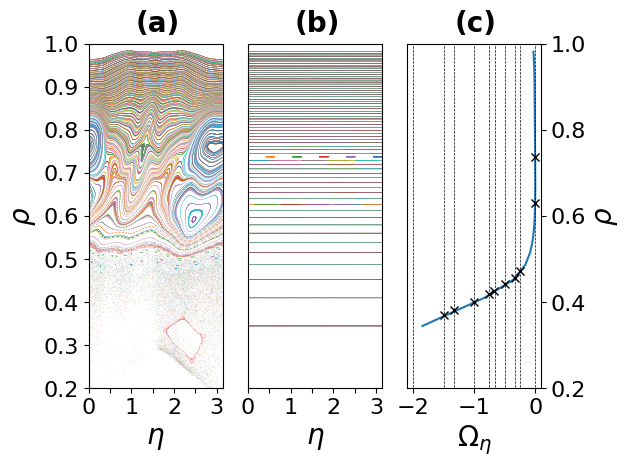

In [73]:
fig,ax = plt.subplots(nrows=1,ncols=3)

# Poincare_plot plotting
for j in [0,1]:
    ax[j].set_xlabel(r"$\eta$",fontsize=20)
    ax[j].set_ylabel(r"$\rho$",fontsize=20)
    # ax[j].set_xlim([0, 2 * np.pi])
    ax[j].set_ylim([0, 1])
    eta_points = []
    s_points = []
    for i in range(len(etas_all[j])):
        ax[j].scatter(
            np.array(etas_all[j][i],dtype=float),
            np.array((s_all[j][i])**0.5,dtype=float),
            marker="o",
            s=0.045,
            edgecolors="none",
            rasterized=True
        )

ax[2].plot(omega_zetas,s_profs**0.25)
ax[2].set_xlabel(r'$\Omega_{\eta}$',fontsize=20)
ax[2].yaxis.set_label_position("right")
ax[2].yaxis.tick_right()
ax[2].set_ylabel(r'$\rho$',fontsize=20)
ax[2].set_ylim(0.2,1.0)
ax[2].set_xlim(-2.1,0.1)
# ax[2].legend(loc='upper left',bbox_to_anchor=(-1.26, 1.175))
ax[0].set_xlim([0,2*np.pi])
ax[1].set_xlim([0,2*np.pi])
ax[0].set_xticks([0, 1, 2, 3,4,5,6])
ax[0].set_xticklabels([str(0), '',str(1),'', str(2), '',str(3)],fontsize=16)
ax[1].set_xticks([0, 1, 2, 3,4,5,6])
ax[1].set_xticklabels([str(0), '',str(1),'', str(2), '',str(3)],fontsize=16)
colors_plot = ['bx','rx']
# m=0
for res in res_arr:
    ax[2].plot([res,res],[0,1],'k--',lw=0.5)
    i=0
    for j in range(0,len(s_profs)-1): # loop through each s
        res_dist_curr = omega_zetas[j] - res
        res_dist_next = omega_zetas[j+1] - res
        if np.sign(res_dist_curr)==np.sign(res_dist_next):
            continue # no res crossing found
        else: # res crossing found
            xs=np.linspace(omega_zetas[j],omega_zetas[j+1],100)
            ses = np.linspace(s_profs[j],s_profs[j+1],100)
            x_plot=999999999
            k_plot=0
            k=0
            for x in xs:
                if abs(x-res) < abs(x_plot-res):
                    x_plot = x
                    k_plot = k
                k+=1
            ax[2].plot(x_plot,(ses[k_plot])**0.25,'kx')
        # if abs(omega_zeta[j]) < zero_cross and m==0:
        #     zero_cross = omega_zeta[j]
        #     zero_cross_s = s_profs[i][j]
    i+=1
# m+=1

# Extra for Poincare Plot 1
ax[1].yaxis.set_visible(False)
ax[1].set_ylim([0.2,1.0])
ax[0].set_ylim([0.2,1.0])


# Add a b and c labels
labels = [item.get_text() for item in ax[0].get_yticklabels()]
# labels[-1]=''
ax[0].set_yticklabels(labels,fontsize=16)
labels = ['(a)', '(b)', '(c)']

for i, a in enumerate(ax):
    a.text(
        0.35, 1.1, labels[i],
        transform=a.transAxes,  # use axes coordinates (0–1)
        fontsize=20,
        fontweight='bold',
        va='top', ha='left'
    )

ax[2].set_xticks([0, -1, -2])
ax[2].tick_params(axis='x', labelsize=16)
ax[2].tick_params(axis='y', labelsize=16)

plt.tight_layout()
plt.savefig("poincare_omega_poster.pdf")
plt.savefig("poincare_omega_poster.png")

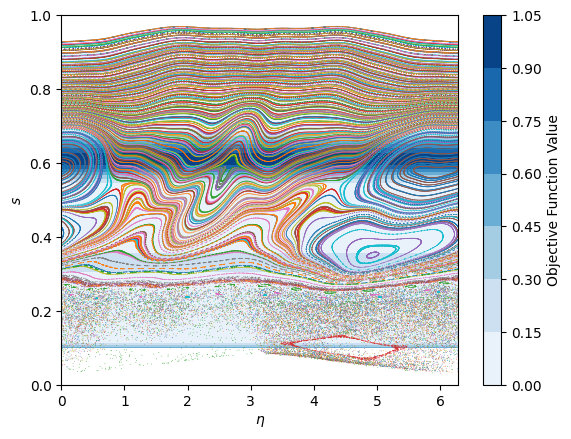

In [25]:
fig1,ax1 = plt.subplots()
# Poincare_plot plotting
ax1.set_xlabel(r"$\eta$")
ax1.set_ylabel(r"$s$")
# ax[j].set_xlim([0, 2 * np.pi])
ax1.set_ylim([0, 1])
eta_points = []
s_points = []


obj_out = np.load("forpoinc_QI.npy") 
obj_out = obj_out / np.max(obj_out)
rhos = (np.linspace(0.1,0.9,50))**(1/2) # rho = sqrt(s)
Y = rhos**2 # plotting s
X = np.linspace(0,2*np.pi,5)
Z = np.transpose(np.tile(obj_out, (5, 1)))
# ax1 = fig1.axes[0]
cs = ax1.contourf(X,Y,Z,cmap='Blues')
fig1.colorbar(cs, ax=ax1,label="Objective Function Value")

for i in range(len(etas_all[0])):
    ax1.scatter(
        np.array(etas_all[0][i],dtype=float),
        np.array(s_all[0][i],dtype=float),
        marker="o",
        s=0.3,
        edgecolors="none",
        rasterized=True
    )

# plt.savefig("objective_poincare_overlay.pdf")


/var/folders/1s/jh18wdb5059c0177d80bb_xc0000gn/T/ipykernel_69042/3420298763.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues')


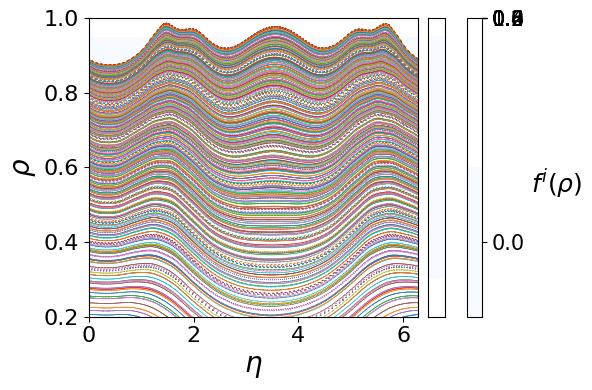

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm, colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

# -----------------------
# Example / your setup
# -----------------------
fig1, ax1 = plt.subplots(figsize=(6, 4))

ax1.set_xlabel(r"$\eta$",fontsize=20)
ax1.set_ylabel(r"$\rho$",fontsize=20)
ax1.set_ylim([0, 1])

obj_out = np.load("forpoinc_QI.npy") 
# obj_out = obj_out / np.max(obj_out)

rhos = (np.linspace(0.1, 0.9, 50)) ** (1/2)
Y = rhos
X = np.linspace(0, 2*np.pi, 5)
Z = np.transpose(np.tile(obj_out, (5, 1)))  # shape (50, 5)

# -----------------------
# Shared colormap + normalization
# -----------------------
cmap = cm.get_cmap('Blues')
norm = colors.Normalize(vmin=0, vmax=1)

# -----------------------
# Contour plot (uses shared cmap/norm)
# -----------------------
cs = ax1.contourf(X, Y, Z, cmap=cmap, norm=norm)
cbar = fig1.colorbar(cs, ax=ax1, label=r"$f^i(\rho)$")
cbar.set_label(r"$f^i(\rho)$", rotation=0, labelpad=23, fontsize=18)

# (Optional) scatter overlay
for i in range(len(etas_all[0])):
    for j in range(0,len(s_all[0][i])):
        if s_all[0][i][j] < 0:
            s_all[0][i][j] = 0
            # etas_all[0][i][j]
    ax1.scatter(np.array(etas_all[0][i],dtype=float),
                (np.array(s_all[0][i],dtype=float))**0.5,
                marker="o", s=0.3, edgecolors="none", rasterized=True)

# -----------------------
# Add the 1D color strip to the right
# -----------------------
divider = make_axes_locatable(ax1)
cax_strip = divider.append_axes("right", size="5%", pad=0.1)
ax1.set_ylim([0.2,1.0])


# reshape obj_out → vertical strip
obj_out_2d = obj_out.reshape(-1, 1)
# cax_strip.imshow(
#     obj_out_2d,
#     aspect='auto',
#     cmap=cmap,
#     norm=norm,           # 🔹 ensures colors match contour plot
#     origin='lower',
#     extent=(0, 1, *ax1.get_ylim())
# )
N = obj_out_2d.shape[0]

# Compute edges for the non-uniform rhos (length N+1)
# midpoints between adjacent rhos
midpoints = 0.5 * (rhos[:-1] + rhos[1:])          # length N-1
# edges: extrapolate outward for the first and last edges
y_edges = np.empty(N + 1)
y_edges[1:-1] = midpoints
y_edges[0] = rhos[0] - (midpoints[0] - rhos[0])
y_edges[-1] = rhos[-1] + (rhos[-1] - midpoints[-1])
x_edges = np.array([0.0, 1.0])  # length 2 -> nx = 1

pcm = cax_strip.pcolormesh(x_edges, y_edges, obj_out_2d,
                           cmap=cmap, norm=norm, shading='flat')
cax_strip.set_ylim([0.2,1.0])

# clean up the strip axis
cax_strip.set_xticks([])
# cax_strip.set_ylabel("ρ² (s)")
# cax_strip.yaxis.set_label_position("right")
# cax_strip.yaxis.tick_right()
cax_strip.yaxis.set_visible(False)

ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)
cbar.ax.tick_params(labelsize=15)
cbar.set_ticks(np.linspace(0, 1.0, 6))


plt.tight_layout()
plt.savefig("objective_poincare_overlay.pdf")


In [15]:
print(obj_out)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
